In [40]:
import pandas as pd
from pathlib import Path

import os
ROOT_DIR = os.path.join(os.getcwd(), '..', '..')
CSV_PATH = os.path.join(ROOT_DIR, "resultados","resultados_modelos.csv")
# 1) Cargar CSV (separado por ;)
df = pd.read_csv(CSV_PATH, sep=";", decimal=",", engine="python")

# 2) Filtrar filas válidas (descartar NaN en modelo)
df = df[df["Modelo"].notna()].copy()

# 3) Seleccionar columnas necesarias
cols_originales = {
    "Modelo": "Model",
    "mean_coleman_liau": "CLI",
    "mean_flesch_reading_ease": "FRE",
    "mean_gunning_fog": "GFI",
    "mean_smog_index": "SMOG",
    "mean_flesch_kincaid_grade": "FKGL",
    "mean_dale_chall": "DCRS",
    "mean_alignscore_nli": "AlignScore_NLI",
    "mean_alignscore_bin": "AlignScore_BIN",
    "mean_f1": "BERTScore"
}

df_tabla = df[list(cols_originales.keys())].copy()

# 4) Convertir números con coma a punto
for col in cols_originales.keys():
    if col != "Modelo":  # evitar texto
        df_tabla[col] = df_tabla[col].astype(str).str.replace(",", ".").astype(float)

# 5) Renombrar columnas al formato de tabla
df_tabla = df_tabla.rename(columns=cols_originales)

# Mostrar resultado
df_tabla

,Model,CLI,FRE,GFI,SMOG,FKGL,DCRS,AlignScore_NLI,AlignScore_BIN,BERTScore
0,DeepSeek,13.978,53.312,10.280,11.991,9.844,8.953,0.437,0.642,0.836
1,Gemma3,14.360,53.407,10.364,11.834,9.880,9.531,0.384,0.443,0.814
2,"Llama3,2",13.980,54.948,10.864,11.831,9.827,9.515,0.433,0.472,0.822
3,Qwen3,13.232,54.833,10.497,11.978,9.773,9.029,0.447,0.458,0.831
4,claude_API,9.366,84.082,5.029,7.395,4.207,6.470,0.507,0.674,0.811
5,Gemini_API,7.755,89.067,4.680,6.640,3.348,6.286,0.506,0.549,0.813
6,GPT5_API,9.489,81.925,6.501,7.977,5.246,7.332,0.616,0.655,0.820
7,Grok_API,7.843,89.741,4.274,6.316,2.996,7.102,0.515,0.601,0.815
8,DeepSeek_OPT,12.804,56.916,9.754,11.679,9.173,8.912,0.446,0.647,0.848
9,Gemma3_OPT,14.034,50.973,10.372,12.379,10.222,9.263,0.474,0.688,0.856


PosixPath('/Users/jsoa/Proyecto-PLN-FLAG/resultados/imagenes/text_standard_barras_seaborn.png')

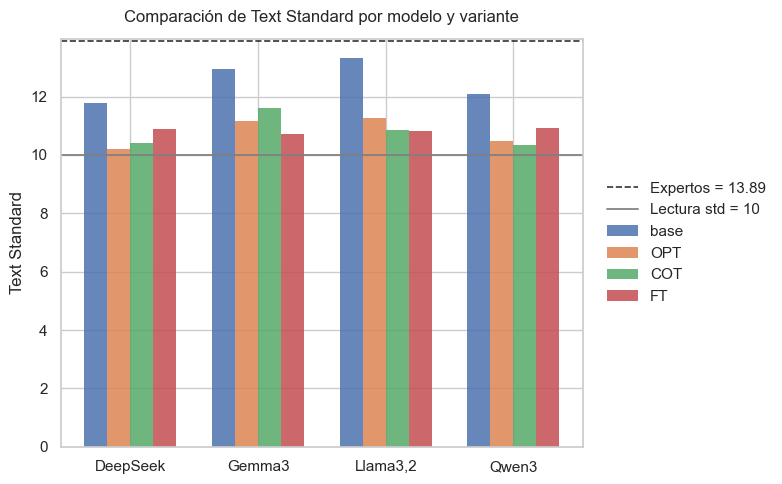

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------------------------------
# Se espera que df tenga estas columnas:
#   - df["Model"]
#   - df["mean_text_standard"]
# -------------------------------------------------------

# Extraer familias principales
df_plot = df.copy()

# familia = nombre base sin sufijos
df_plot["family"] = (
    df_plot["Modelo"]
    .str.replace("_OPT", "", regex=False)
    .str.replace("_COT", "", regex=False)
    .str.replace("_base", "", regex=False)
)

# variante = base / OPT / COT / FT
def get_variant(name: str) -> str:
    if name.endswith("_base"):
        return "base"
    elif name.endswith("_OPT"):
        return "OPT"
    elif name.endswith("_COT"):
        return "COT"
    else:
        return "FT"   # modelo fine-tuned principal

df_plot["variant"] = df_plot["Modelo"].apply(get_variant)

# Orden de familias y variantes
models = ["DeepSeek", "Gemma3", "Llama3,2", "Qwen3"]
variants = ["base", "OPT", "COT", "FT"]

# Tabla pivote: index = familia, columnas = variante
pivot = df_plot.pivot_table(
    index="family",
    columns="variant",
    values="mean_text_standard",
    aggfunc="mean"
)

# Reordenar filas y columnas
pivot = pivot.reindex(index=models)[variants]

# -------------------------------------
#   Gráfico con seaborn estilo bonito
# -------------------------------------

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))

x = np.arange(len(models))
width = 0.18
palette = sns.color_palette("deep", n_colors=len(variants))

# Dibujar barras agrupadas
for i, variant in enumerate(variants):
    heights = pivot[variant].values
    plt.bar(
        x + i*width,
        heights,
        width=width,
        label=variant,
        color=palette[i],
        alpha=0.85,
        edgecolor="none"
    )

# Línea horizontal media experto
expert_mean = 13.89
plt.axhline(expert_mean, linestyle="--", linewidth=1.2, color="black", alpha=0.8,
            label="Expertos = 13.89")
# Línea horizontal de lectura estándar (12)
plt.axhline(
    10,
    linestyle="-",          # línea sólida
    linewidth=1.4,
    color="gray",
    alpha=0.9,
    label="Lectura std = 10"
)
plt.xticks(x + width*1.5, models)
plt.ylabel("Text Standard")
plt.title("Comparación de Text Standard por modelo y variante", pad=12)
plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # → mueve la leyenda a la derecha, fuera del gráfico
    loc="center left",
    frameon=False
)
plt.tight_layout()

# Guardar imagen
NB_DIR = Path().resolve()
ROOT_DIR = (NB_DIR / ".." / "..").resolve()
SEED = 123
output_path = ROOT_DIR / "resultados" / "imagenes" / "text_standard_barras_seaborn.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

output_path

PosixPath('/Users/jsoa/Proyecto-PLN-FLAG/resultados/imagenes/fre_barras_seaborn.png')

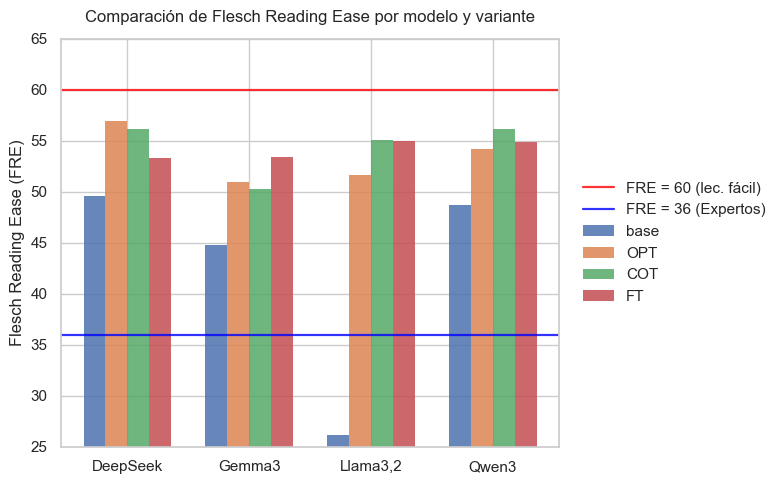

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------------------------------
# df debe tener:
#   - df["Model"]
#   - df["mean_flesch_reading_ease"]
# -------------------------------------------------------

df_plot = df.copy()
df_plot["Modelo"] = df_plot["Modelo"].str.strip()
# Extraer familia base
df_plot["family"] = (
    df_plot["Modelo"]
    .str.replace("_OPT", "", regex=False)
    .str.replace("_COT", "", regex=False)
    .str.replace("_base", "", regex=False)
)

# Variante dentro de cada modelo
def get_variant(name: str) -> str:
    if name.endswith("_base"):
        return "base"
    elif name.endswith("_OPT"):
        return "OPT"
    elif name.endswith("_COT"):
        return "COT"
    else:
        return "FT"

df_plot["variant"] = df_plot["Modelo"].apply(get_variant)

models = ["DeepSeek", "Gemma3", "Llama3,2", "Qwen3"]
variants = ["base", "OPT", "COT", "FT"]

pivot = df_plot.pivot_table(
    index="family",
    columns="variant",
    values="mean_flesch_reading_ease",
    aggfunc="mean"
)

pivot = pivot.reindex(index=models)[variants]

# Estilo seaborn limpio
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))

x = np.arange(len(models))
width = 0.18
palette = sns.color_palette("deep", n_colors=len(variants))

# Barras agrupadas
for i, variant in enumerate(variants):
    heights = pivot[variant].values
    plt.bar(
        x + i*width,
        heights,
        width=width,
        label=variant,
        color=palette[i],
        alpha=0.85,
        edgecolor="none"
    )

# Líneas rojas en 60 (textos fáciles) y 30 (textos difíciles)
plt.axhline(
    60,
    linestyle="-",
    linewidth=1.6,
    color="red",
    alpha=0.8,
    label="FRE = 60 (lec. fácil)"
)

plt.axhline(
    36,
    linestyle="-",
    linewidth=1.6,
    color="Blue",
    alpha=0.8,
    label="FRE = 36 (Expertos)"
)

plt.ylim(25, 80)
plt.ylim(25,  max( pivot.max().max(), 60 ) + 5 )
# Ejes, título y leyenda
plt.xticks(x + width*1.5, models)
plt.ylabel("Flesch Reading Ease (FRE)")
plt.title("Comparación de Flesch Reading Ease por modelo y variante", pad=12)

plt.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

plt.tight_layout()

# Guardar imagen
output_path = ROOT_DIR / "resultados" / "imagenes" / "fre_barras_seaborn.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

output_path